
# Hands-on Reinforcement Learning: Multi-Armed Bandits (MAB)

**Updated:** 2025-08-24 (UTC)

This tutorial walks through the reinforcement learning (RL) workflow using the simplest RL setting: **multi-armed bandits**.  
You'll build a small *environment* and several *policies* (agents) and see how they balance **exploration vs exploitation**.

**What you'll learn**:
- The RL interaction loop (initialize → select action → step environment → observe reward → update → repeat)
- Implementing a Bernoulli multi-armed bandit
- Implementing classic bandit algorithms: ε-greedy (with optional decay), UCB1, and Thompson Sampling
- Measuring performance with **cumulative regret**, action counts, and moving-average reward



## Setup

This notebook uses only standard scientific Python packages.


In [1]:

import numpy as np
import matplotlib.pyplot as plt

# For reproducibility, we fix the random seed
np.random.seed(1)



## Environment: Bernoulli Multi-Armed Bandit

We simulate a slot machine with **K** arms. Pulling arm *k* yields reward 1 with probability `p_k` and 0 otherwise.
The agent does not know the probabilities and must learn by interaction.


In [2]:

class BernoulliBandit:
    """Bernoulli multi-armed bandit with K arms."""
    def __init__(self, K):
        self.probs = np.random.uniform(size=K)   # unknown to the agent
        self.best_idx = int(np.argmax(self.probs))
        self.best_prob = float(self.probs[self.best_idx])
        self.K = int(K)

    def step(self, k: int) -> int:
        """Return a stochastic reward (0 or 1) from arm k."""
        return 1 if np.random.rand() < self.probs[k] else 0

K = 10
bandit = BernoulliBandit(K)
print(f"Created a {K}-armed Bernoulli bandit.")
print(f"Best arm index = {bandit.best_idx}, best success prob = {bandit.best_prob:.4f}")


Created a 10-armed Bernoulli bandit.
Best arm index = 1, best success prob = 0.7203


## Try Multi-Armed Bandit on your own!

This cell lets you play a multi-armed bandit game for a fixed number of rounds.  

- At the beginning, each arm has a hidden success probability.  
- Each round you choose an arm index (0 to K-1).  
- The bandit returns a reward (1 or 0).  
- After all rounds, the program summarizes your total reward, average reward, pull counts, and reveals the best arm with its probability, along with a bar chart of the true probabilities.  

This exercise demonstrates the exploration–exploitation trade-off in reinforcement learning.


🎰 New game: 5-armed bandit, 20 rounds.
Each round, type an arm index (0 ~ {K-1}). Type 'q' to quit early.

  → You pulled arm 4 | reward = 0 | cumulative = 0
  → You pulled arm 4 | reward = 1 | cumulative = 1
  → You pulled arm 4 | reward = 1 | cumulative = 2
  → You pulled arm 4 | reward = 1 | cumulative = 3
  → You pulled arm 4 | reward = 1 | cumulative = 4
  → You pulled arm 4 | reward = 0 | cumulative = 4
  → You pulled arm 4 | reward = 1 | cumulative = 5
  → You pulled arm 4 | reward = 1 | cumulative = 6
  → You pulled arm 4 | reward = 0 | cumulative = 6
  → You pulled arm 4 | reward = 1 | cumulative = 7
  → You pulled arm 4 | reward = 0 | cumulative = 7
  → You pulled arm 4 | reward = 1 | cumulative = 8
  → You pulled arm 4 | reward = 0 | cumulative = 8
  → You pulled arm 4 | reward = 0 | cumulative = 8
  → You pulled arm 4 | reward = 1 | cumulative = 9
  → You pulled arm 4 | reward = 1 | cumulative = 10
  → You pulled arm 4 | reward = 0 | cumulative = 10
  → You pulled arm 4 | r

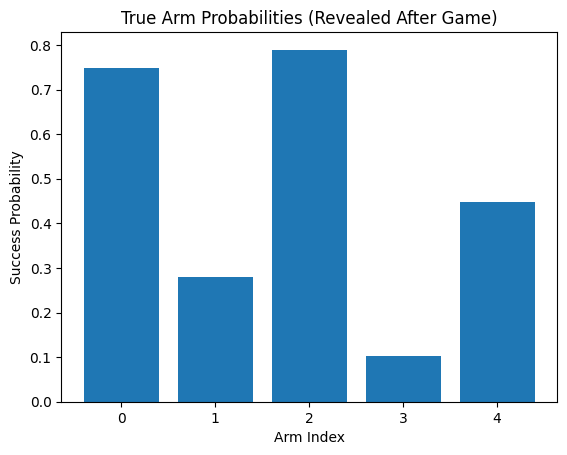


Tip: change K/ROUNDS at the top for difficulty, or play multiple times to feel exploration vs. exploitation!


In [5]:
ROUNDS = 20
bandit = BernoulliBandit(K=K)

print(f"🎰 New game: {K}-armed bandit, {ROUNDS} rounds.")
print("Each round, type an arm index (0 ~ {K-1}). Type 'q' to quit early.\n")

# ----- Play k rounds -----
actions, rewards = [], []
for t in range(1, ROUNDS + 1):
    while True:
        s = input(f"Round {t}/{ROUNDS} - choose an arm [0..{K-1}] (or 'q'): ").strip().lower()
        if s in ("q", "quit", "exit"):
            print("Ending the game early.\n")
            # jump out of both loops
            break
        try:
            k = int(s)
            if 0 <= k < K:
                break
            else:
                print(f"Please enter an integer in [0, {K-1}].")
        except ValueError:
            print("Invalid input. Enter an integer arm index or 'q'.")
    if s in ("q", "quit", "exit"):
        break

    r = bandit.step(k)
    actions.append(k)
    rewards.append(r)
    print(f"  → You pulled arm {k} | reward = {r} | cumulative = {sum(rewards)}")

n = len(actions)
print("\n===== Game Summary =====")
if n == 0:
    print("No pulls were made. Run the cell again to play.")
else:
    total = int(np.sum(rewards))
    avg = float(np.mean(rewards))
    counts = np.bincount(actions, minlength=K)
    # pseudo-regret using known best mean (revealed after the game)
    pseudo_regret = n * bandit.best_prob - sum(bandit.probs[k] for k in actions)

    print(f"Rounds played: {n}")
    print(f"Total reward: {total}")
    print(f"Average reward: {avg:.3f}")
    print(f"Your pull counts by arm: {counts.tolist()}")
    print(f"Pseudo-regret (revealed post-game): {pseudo_regret:.3f}")

    print("\n Reveal (after the game):")
    print(f"  • Best arm index: {bandit.best_idx}")
    print(f"  • Best arm true success prob: {bandit.best_prob:.3f}")
    # Optional: show all probabilities
    # print("  • All arm probabilities:", np.round(bandit.probs, 3))

    # ----- Visualizations -----

    # Reveal true arm probabilities after game
    plt.figure()
    plt.bar(range(K), bandit.probs)
    plt.title("True Arm Probabilities (Revealed After Game)")
    plt.xlabel("Arm Index")
    plt.ylabel("Success Probability")
    plt.show()

print("\nTip: change K/ROUNDS at the top for difficulty, or play multiple times to feel exploration vs. exploitation!")


## The RL Loop (Bandit Edition)

At each time step *t = 1, 2, ...*  
1. **Select action** `a_t` (which arm to pull) according to a *policy* (e.g., ε-greedy, UCB, Thompson).  
2. **Step environment** with `a_t` → observe **reward** `r_t`.  
3. **Update** your policy's estimates/statistics.  
4. **Repeat**.

We will code a small base class `Solver` to capture shared bookkeeping (counts, cumulative regret, etc.).


In [6]:

class Solver:
    """Common framework for bandit solvers/policies."""
    def __init__(self, bandit: BernoulliBandit):
        self.bandit = bandit
        self.counts = np.zeros(self.bandit.K, dtype=int)  # pulls per arm
        self.regret = 0.0
        self.actions = []
        self.regrets = []

    def update_regret(self, k: int):
        # Regret = (best expected reward) - (expected reward of chosen arm)
        self.regret += self.bandit.best_prob - self.bandit.probs[k]
        self.regrets.append(self.regret)

    def run_one_step(self) -> int:
        raise NotImplementedError

    def run(self, num_steps: int):
        for _ in range(num_steps):
            k = self.run_one_step()
            self.counts[k] += 1
            self.actions.append(k)
            self.update_regret(k)



## ε-Greedy (with optional decay)

With probability **ε**, explore (choose a random arm). Otherwise, **exploit** the current best estimate.
We keep an **incremental** estimate of each arm's mean reward.


In [7]:

class EpsilonGreedy(Solver):
    def __init__(self, bandit: BernoulliBandit, epsilon: float = 0.1, init_value: float = 1.0, decay: float = 0.0):
        super().__init__(bandit)
        self.epsilon = float(epsilon)
        self.decay = float(decay)   # per-step multiplicative decay for epsilon (e.g., 0.999)
        self.estimates = np.full(self.bandit.K, float(init_value), dtype=float)
        self.n = np.zeros(self.bandit.K, dtype=int)

    def run_one_step(self) -> int:
        # Explore vs exploit
        if np.random.rand() < self.epsilon:
            k = np.random.randint(0, self.bandit.K)
        else:
            k = int(np.argmax(self.estimates))

        # Observe reward and update incremental mean
        r = self.bandit.step(k)
        self.n[k] += 1
        self.estimates[k] += (r - self.estimates[k]) / self.n[k]

        # Optional epsilon decay
        if self.decay > 0:
            self.epsilon *= self.decay
        return k



## Experiment Utilities


In [8]:

def run_solvers(bandit, solvers, num_steps=2000):
    for s in solvers:
        s.run(num_steps=num_steps)

def plot_cumulative_regret(solvers):
    plt.figure()
    for s in solvers:
        plt.plot(s.regrets, label=s.__class__.__name__)
    plt.xlabel('Steps')
    plt.ylabel('Cumulative Regret')
    plt.legend()
    plt.show()

def plot_action_counts(solvers):
    plt.figure()
    width = 0.8 / len(solvers)
    x = np.arange(solvers[0].bandit.K)
    for i, s in enumerate(solvers):
        plt.bar(x + i*width, s.counts, width=width, label=s.__class__.__name__)
    plt.xlabel('Arm Index')
    plt.ylabel('Pull Count')
    plt.legend()
    plt.show()

def plot_moving_average_reward(solvers, window=50):
    plt.figure()
    for s in solvers:
        rewards = []
        # reconstruct rewards from actions for visualization
        for k in s.actions:
            rewards.append(1 if np.random.rand() < s.bandit.probs[k] else 0)
        rewards = np.array(rewards, dtype=float)
        if len(rewards) >= window:
            ma = np.convolve(rewards, np.ones(window)/window, mode='valid')
            plt.plot(ma, label=s.__class__.__name__)
    plt.xlabel(f'Steps (window={window})')
    plt.ylabel('Moving Avg Reward')
    plt.legend()
    plt.show()



## Demo

Let's compare ε-Greedy, UCB1, and Thompson Sampling on the **same** bandit instance.


Best arm = 1, prob = 0.720


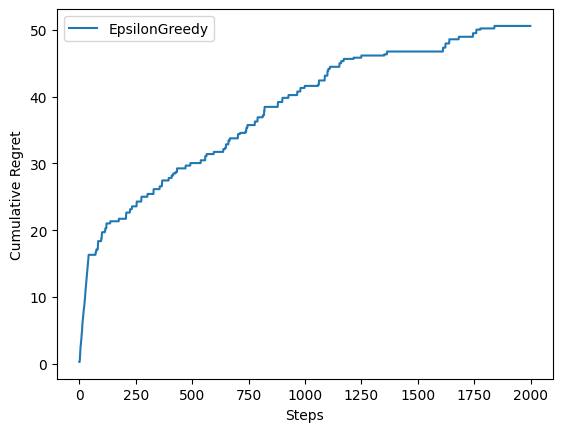

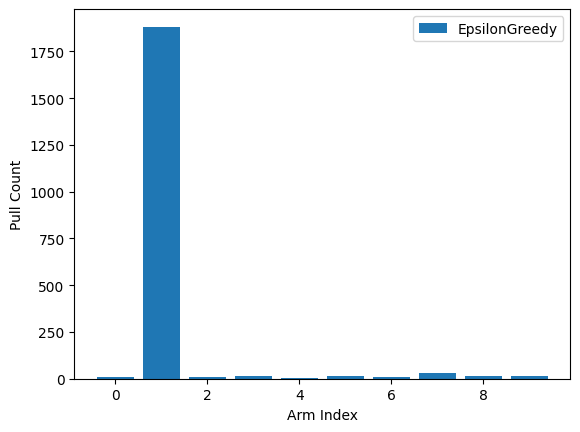

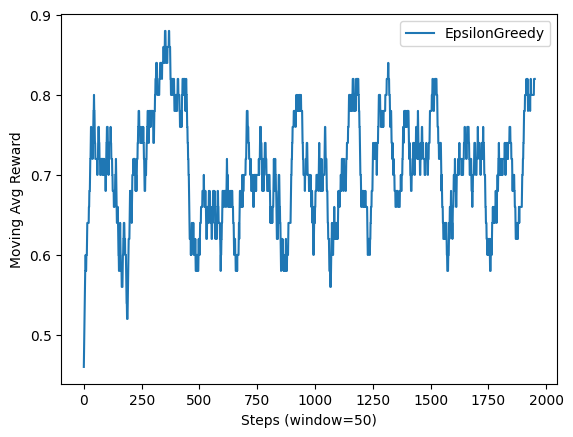

In [9]:

# Create a fresh bandit instance for fairness
np.random.seed(1)
bandit = BernoulliBandit(K=10)
print(f"Best arm = {bandit.best_idx}, prob = {bandit.best_prob:.3f}")

solvers = [
    EpsilonGreedy(bandit, epsilon=0.1, init_value=1.0, decay=0.999),
]

run_solvers(bandit, solvers, num_steps=2000)

plot_cumulative_regret(solvers)
plot_action_counts(solvers)
plot_moving_average_reward(solvers, window=50)



## Discussion & Next Steps

- **ε-Greedy** is simple and effective; using optimistic initial values or a decaying ε helps exploration early on.
- **UCB1** provides a principled confidence-bound trade-off and typically achieves low regret.
- **Thompson Sampling** is a Bayesian approach that often performs very well in practice.

**Extensions**:
- Non-stationary bandits (e.g., with a sliding-window or discounted updates)
- Contextual bandits (features → arm selection)
- Full RL with states and transitions (Markov Decision Processes)

Happy exploring!
